In [80]:
from pathlib import Path
import pandas as pd

# Load the dataset and count rows
DATA_PATH = Path("/Users/samyukrishnasamy/DS3001-Final/mxmh_survey_results.csv")


df = pd.read_csv(DATA_PATH)

In [81]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
)
df.columns


Index(['timestamp', 'age', 'primary_streaming_service', 'hours_per_day',
       'while_working', 'instrumentalist', 'composer', 'fav_genre',
       'exploratory', 'foreign_languages', 'bpm', 'frequency_classical',
       'frequency_country', 'frequency_edm', 'frequency_folk',
       'frequency_gospel', 'frequency_hip_hop', 'frequency_jazz',
       'frequency_k_pop', 'frequency_latin', 'frequency_lofi',
       'frequency_metal', 'frequency_pop', 'frequency_r&b', 'frequency_rap',
       'frequency_rock', 'frequency_video_game_music', 'anxiety', 'depression',
       'insomnia', 'ocd', 'music_effects', 'permissions'],
      dtype='object')

In [82]:
freq_cols = [
    "frequency_classical",
    "frequency_country",
    "frequency_edm",
    "frequency_folk",
    "frequency_gospel",
    "frequency_hip_hop",
    "frequency_jazz",
    "frequency_k_pop",
    "frequency_latin",
    "frequency_lofi",
    "frequency_metal",
    "frequency_pop",
    "frequency_r&b",
    "frequency_rap",
    "frequency_rock",
    "frequency_video_game_music"
]

use_cols = [
    "hours_per_day",
    "age",
    "while_working",
    "exploratory",
    "foreign_languages",
    "anxiety",
    "depression",
    "insomnia",
    "ocd"
] + freq_cols

df = df[use_cols].copy()
df.head()


,hours_per_day,age,while_working,exploratory,foreign_languages,anxiety,depression,insomnia,ocd,frequency_classical,...,frequency_jazz,frequency_k_pop,frequency_latin,frequency_lofi,frequency_metal,frequency_pop,frequency_r&b,frequency_rap,frequency_rock,frequency_video_game_music
0,3.0,18.0,Yes,Yes,Yes,3.0,0.0,1.0,0.0,Rarely,...,Never,Very frequently,Very frequently,Rarely,Never,Very frequently,Sometimes,Very frequently,Never,Sometimes
1,1.5,63.0,Yes,Yes,No,7.0,2.0,2.0,1.0,Sometimes,...,Very frequently,Rarely,Sometimes,Rarely,Never,Sometimes,Sometimes,Rarely,Very frequently,Rarely
2,4.0,18.0,No,No,Yes,7.0,7.0,10.0,2.0,Never,...,Rarely,Very frequently,Never,Sometimes,Sometimes,Rarely,Never,Rarely,Rarely,Very frequently
3,2.5,61.0,Yes,Yes,Yes,9.0,7.0,3.0,3.0,Sometimes,...,Very frequently,Sometimes,Very frequently,Sometimes,Never,Sometimes,Sometimes,Never,Never,Never
4,4.0,18.0,Yes,Yes,No,7.0,2.0,5.0,9.0,Never,...,Never,Very frequently,Sometimes,Sometimes,Never,Sometimes,Very frequently,Very frequently,Never,Rarely


In [83]:
yn_cols = ["while_working", "exploratory", "foreign_languages"]

for col in yn_cols:
    df[col] = df[col].replace({"Yes": 1, "No": 0})


/var/folders/28/snq1pkyd68jdmfy73dssxll40000gn/T/ipykernel_61584/2352363752.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({"Yes": 1, "No": 0})


In [84]:
freq_map = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Very frequently": 3
}

for col in freq_cols:
    df[col] = df[col].map(freq_map)


In [85]:
df["freq_hiphop_rap"] = df[["frequency_hip_hop", "frequency_rap"]].max(axis=1)
df["freq_rock_metal"] = df[["frequency_rock", "frequency_metal"]].max(axis=1)
df["freq_edm_lofi_vgm"] = df[["frequency_edm", "frequency_lofi", "frequency_video_game_music"]].max(axis=1)
df["freq_country_folk"] = df[["frequency_country", "frequency_folk"]].max(axis=1)
df["freq_randb_gospel"] = df[["frequency_r&b", "frequency_gospel"]].max(axis=1)

df["freq_classical"] = df["frequency_classical"]
df["freq_jazz"] = df["frequency_jazz"]
df["freq_pop"] = df["frequency_pop"]
df["freq_latin"] = df["frequency_latin"]
df["freq_kpop"] = df["frequency_k_pop"]

freq_grouped = [
    "freq_hiphop_rap",
    "freq_rock_metal",
    "freq_edm_lofi_vgm",
    "freq_country_folk",
    "freq_randb_gospel",
    "freq_classical",
    "freq_jazz",
    "freq_pop",
    "freq_latin",
    "freq_kpop"
]


In [86]:
def clean_group_name(name):
    return name.replace("freq_", "").replace("_", " ").title()

def get_genre_list_grouped(row):
    scores = row[freq_grouped]
    max_val = scores.max()

    if max_val == 0 or pd.isna(max_val):
        return ["unknown"]

    tied = scores[scores == max_val].index.tolist()
    tied = [clean_group_name(c) for c in tied]
    tied.sort()

    return tied

df["genre_list"] = df.apply(get_genre_list_grouped, axis=1)
df["genre_list"].head()

0      [Hiphop Rap, Kpop, Latin, Pop]
1                  [Jazz, Rock Metal]
2                [Edm Lofi Vgm, Kpop]
3                       [Jazz, Latin]
4    [Hiphop Rap, Kpop, Randb Gospel]
Name: genre_list, dtype: object

In [87]:
from collections import Counter

counter = Counter()

for lst in df["genre_list"]:
    counter.update(lst)

pd.Series(counter).sort_values(ascending=False)

Rock Metal      405
Pop             308
Edm Lofi Vgm    245
Hiphop Rap      175
Randb Gospel    145
Country Folk    131
Classical       129
Kpop             80
Jazz             69
Latin            36
dtype: int64

### Class Imbalance Analysis

To understand how evenly distributed our multi label genre targets were, we calculated the number of listeners associated with each grouped genre. The results show a clear imbalance. Rock Metal, Pop, and EDM Lofi VGM were the most common categories, accounting for more than half of all genre selections. In contrast, Latin, Jazz, and Kpop appeared much less frequently.

This imbalance affects model training because neural networks tend to favor majority classes. As a result, minority genres may achieve lower recall or require techniques such as weighted loss functions or threshold adjustment to improve fairness across classes.

In [88]:
final_cols = [
    "hours_per_day",
    "age",
    "while_working",
    "exploratory",
    "foreign_languages",
    "anxiety",
    "depression",
    "insomnia",
    "ocd",

    # grouped genres
    "freq_hiphop_rap",
    "freq_rock_metal",
    "freq_edm_lofi_vgm",
    "freq_country_folk",
    "freq_randb_gospel",
    "freq_classical",
    "freq_jazz",
    "freq_pop",
    "freq_latin",
    "freq_kpop",

    # multi label genre target
    "genre_list"
]


In [89]:
df = df[final_cols].copy()
df.head()

,hours_per_day,age,while_working,exploratory,foreign_languages,anxiety,depression,insomnia,ocd,freq_hiphop_rap,freq_rock_metal,freq_edm_lofi_vgm,freq_country_folk,freq_randb_gospel,freq_classical,freq_jazz,freq_pop,freq_latin,freq_kpop,genre_list
0,3.0,18.0,1.0,1,1.0,3.0,0.0,1.0,0.0,3,0,2,0,2,1,0,3,3,3,"[Hiphop Rap, Kpop, Latin, Pop]"
1,1.5,63.0,1.0,1,0.0,7.0,2.0,2.0,1.0,1,3,1,1,2,2,3,2,2,1,"[Jazz, Rock Metal]"
2,4.0,18.0,0.0,0,1.0,7.0,7.0,10.0,2.0,1,2,3,0,0,0,1,1,0,3,"[Edm Lofi Vgm, Kpop]"
3,2.5,61.0,1.0,1,1.0,9.0,7.0,3.0,3.0,0,0,2,1,2,2,3,2,3,2,"[Jazz, Latin]"
4,4.0,18.0,1.0,1,0.0,7.0,2.0,5.0,9.0,3,0,2,0,3,0,0,2,2,3,"[Hiphop Rap, Kpop, Randb Gospel]"


In [ ]:
df.to_csv("mxmh_cleaned.csv", index=False)

# Plots

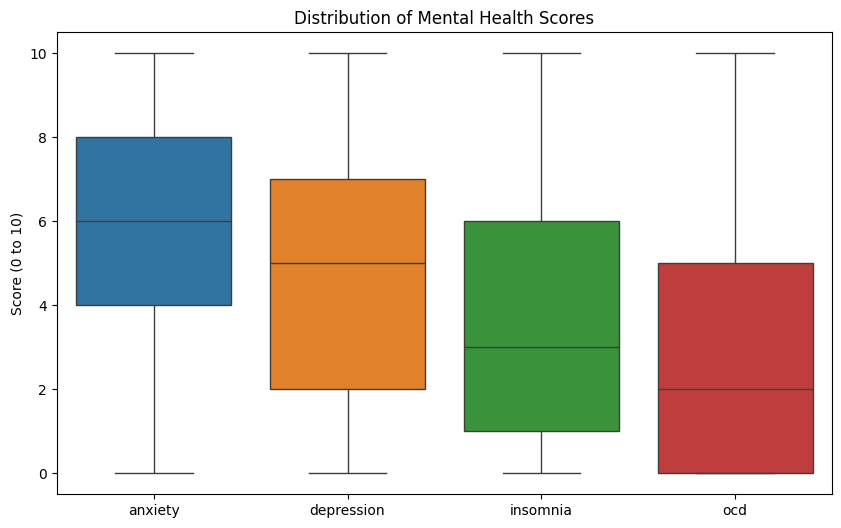

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

mh_cols = ["anxiety", "depression", "insomnia", "ocd"]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[mh_cols])
plt.title("Distribution of Mental Health Scores")
plt.ylabel("Score (0 to 10)")
plt.show()


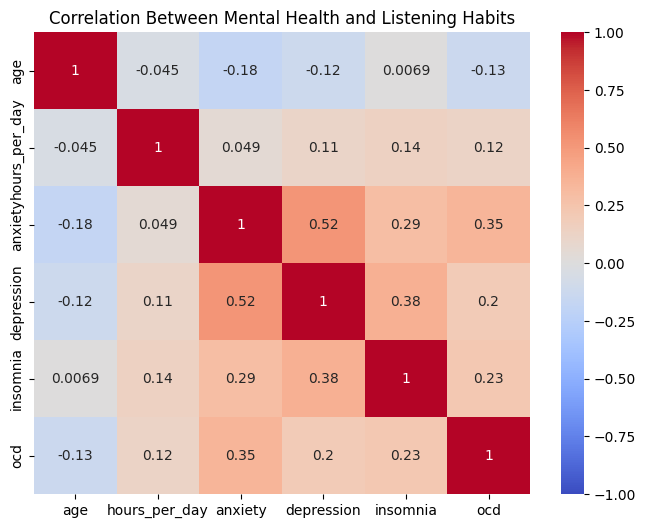

In [91]:
corr_cols = ["age", "hours_per_day", "anxiety", "depression", "insomnia", "ocd"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Mental Health and Listening Habits")
plt.show()


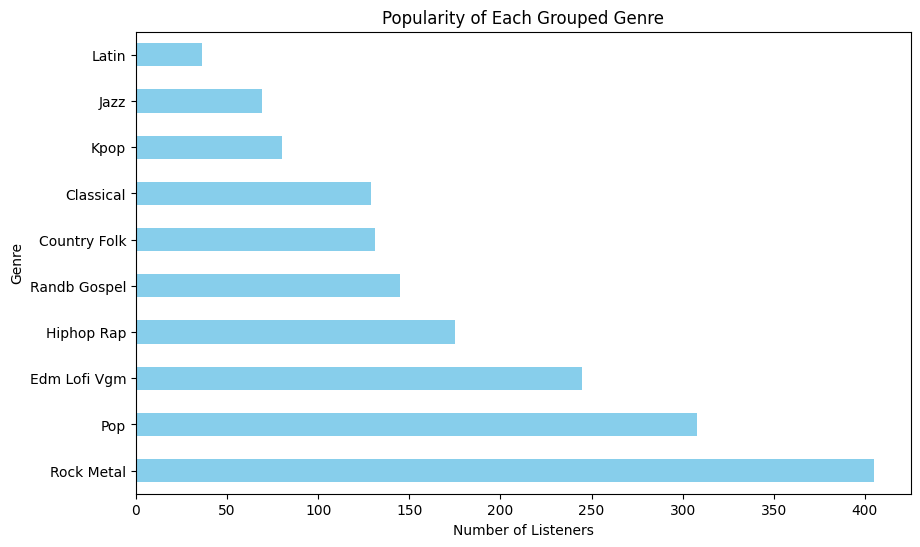

In [92]:
genre_counts = df.explode("genre_list")["genre_list"].value_counts()

genre_counts.plot(kind="barh", figsize=(10, 6), color="skyblue")
plt.title("Popularity of Each Grouped Genre")
plt.xlabel("Number of Listeners")
plt.ylabel("Genre")
plt.show()


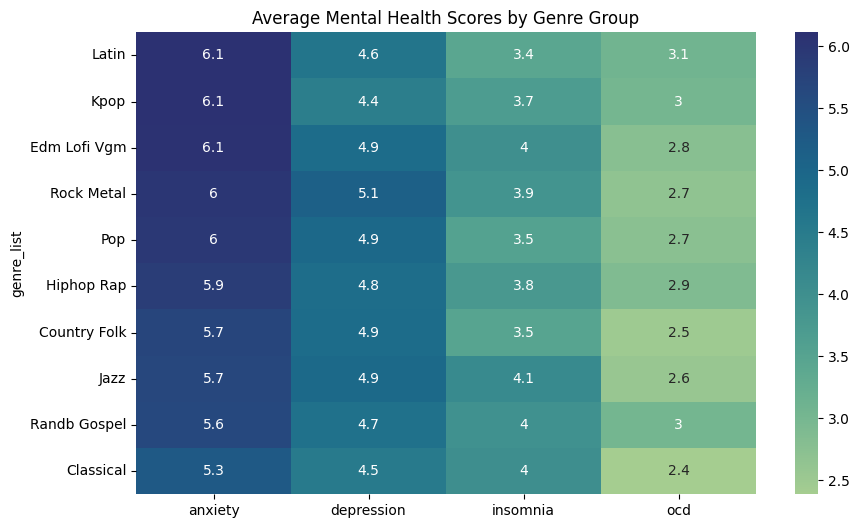

In [93]:
df_exploded = df.explode("genre_list")

mh_per_genre = df_exploded.groupby("genre_list")[mh_cols].mean().sort_values("anxiety", ascending=False)

plt.figure(figsize=(10, 6))
sns.heatmap(mh_per_genre, annot=True, cmap="crest")
plt.title("Average Mental Health Scores by Genre Group")
plt.show()


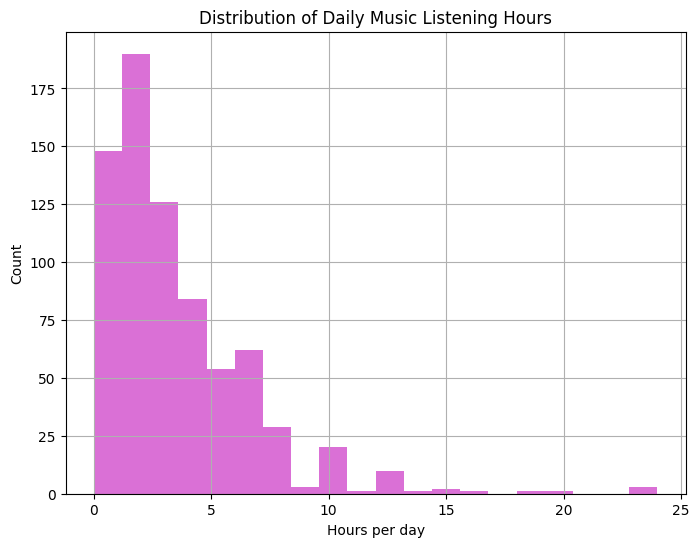

In [94]:
plt.figure(figsize=(8, 6))
df["hours_per_day"].hist(bins=20, color="orchid")
plt.title("Distribution of Daily Music Listening Hours")
plt.xlabel("Hours per day")
plt.ylabel("Count")
plt.show()


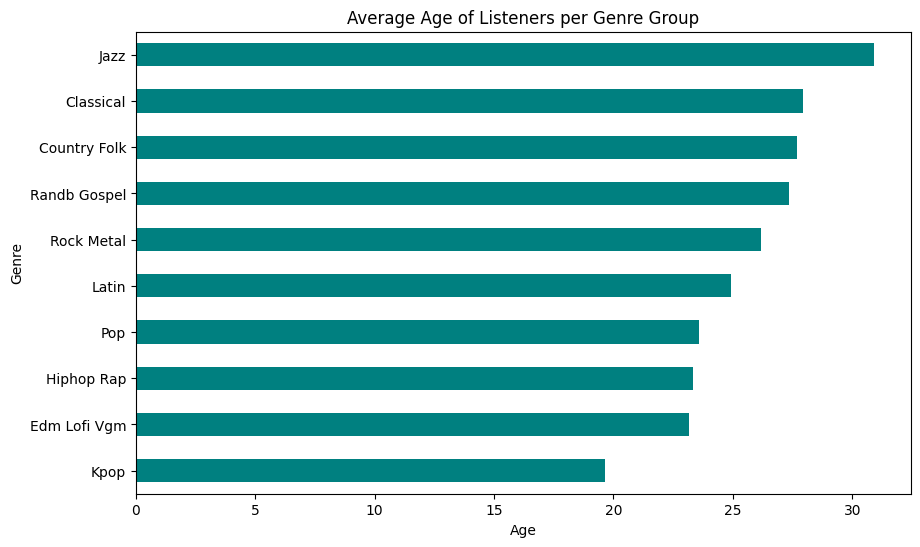

In [95]:
age_by_genre = df_exploded.groupby("genre_list")["age"].mean().sort_values()

age_by_genre.plot(kind="barh", figsize=(10, 6), color="teal")
plt.title("Average Age of Listeners per Genre Group")
plt.xlabel("Age")
plt.ylabel("Genre")
plt.show()


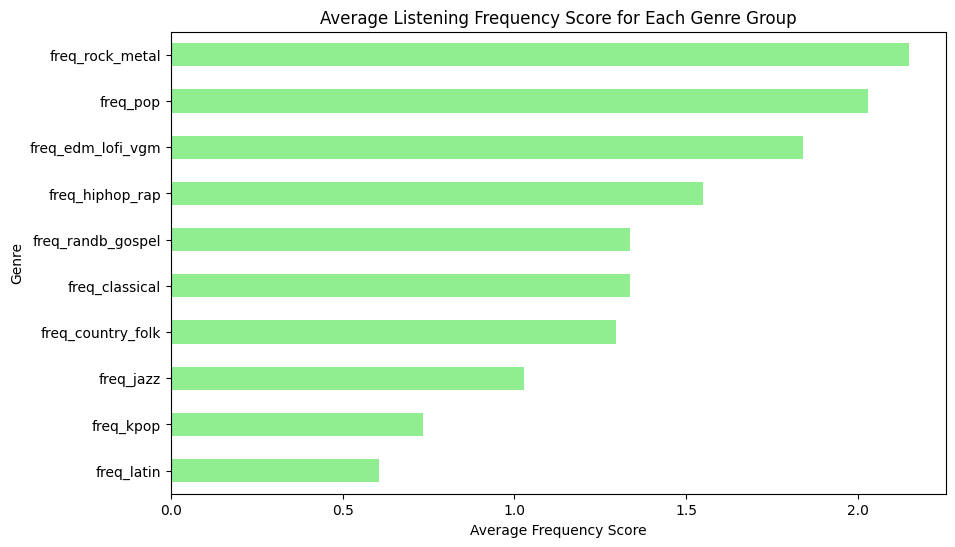

In [96]:
df[freq_grouped].mean().sort_values().plot(kind="barh", figsize=(10, 6), color="lightgreen")
plt.title("Average Listening Frequency Score for Each Genre Group")
plt.xlabel("Average Frequency Score")
plt.ylabel("Genre")
plt.show()
